# 02 — Data Preprocessing
## Fetal Health Classification — Group 16

**Purpose:** Prepare the cleaned CTG dataset for modelling: feature scaling, train/test
split, and SMOTE applied to the training set only (to avoid data leakage).

This directly implements the methodology proposed in Section 4 of the Initial Proposal:
*"Feature scaling and correlation analysis will be performed, and SMOTE will be applied
to address the underrepresentation of pathological cases prior to modelling."*

Correlation analysis was completed in `01_eda.ipynb`. This notebook focuses on scaling,
splitting, and SMOTE.

## 1. Data Loading and Cleaning

This reuses the same cleaning logic as the EDA notebook, so the dataset used for
preprocessing exactly matches the one EDA was performed on:
- Extract proper column headers from row 2 of the raw file (the header structure
  is messy in the original Excel sheet)
- Convert all values to numeric, remove duplicate columns/rows
- Keep only the 21 official CTG features plus the NSP target
- Drop rows where NSP itself is missing, since they can't be used for training

In [19]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
print("Libraries Loaded Successfully")

file_path = Path("../data/raw/CTG.xls")
raw_df = pd.read_excel(file_path, sheet_name="Data", header=None)

columns = raw_df.iloc[1].astype(str)
new_cols = []
counts = {}
for col in columns:
    if col in counts:
        counts[col] += 1
        new_cols.append(f"{col}_{counts[col]}")
    else:
        counts[col] = 0
        new_cols.append(col)

df = raw_df.iloc[2:].copy()
df.columns = new_cols
df = df.loc[:, ~df.columns.str.contains('nan', na=True)]

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.drop_duplicates().reset_index(drop=True)
df = df.loc[:, ~df.columns.duplicated()]
df = df.drop_duplicates().reset_index(drop=True)

ctg_features = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV',
                'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros',
                'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'NSP']

df = df[ctg_features].copy()
df = df.drop_duplicates().reset_index(drop=True)
df = df.dropna(subset=["NSP"]).reset_index(drop=True)

print("Cleaned Dataset Shape:", df.shape)
print("Missing values remaining:", df.isnull().sum().sum())

# Save the cleaned dataset (pre-scaling, pre-split) for reuse by other notebooks
cleaned_path = Path("../data/processed/cleaned_ctg_data.csv")
cleaned_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(cleaned_path, index=False)
print(f"Cleaned dataset saved to {cleaned_path}")

Libraries Loaded Successfully
Cleaned Dataset Shape: (2112, 22)
Missing values remaining: 0
Cleaned dataset saved to ../data/processed/cleaned_ctg_data.csv


## 2. Feature/Target Split

Separate the 21 CTG features (X) from the target variable NSP (y).

**Note on multicollinearity:** EDA identified very strong correlations between
Mode/Mean/Median (r > 0.7) and Width/Min (r = -0.9). These features are retained at
this stage rather than dropped, since:
1. Tree-based ensemble methods (planned in Section 4 of the proposal) are robust to
   multicollinearity, unlike linear models such as Logistic Regression.
2. SHAP analysis (also planned) will identify which of these correlated features
   actually contribute most to predictions, providing an evidence-based way to
   simplify the feature set later if needed, rather than removing features now
   based on correlation alone.

In [20]:
feature_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV',
                'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros',
                'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

X = df[feature_cols].copy()
y = df["NSP"].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target classes:", sorted(y.unique()))

Features shape: (2112, 21)
Target shape: (2112,)
Target classes: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]


## 3. Train/Test Split

Split BEFORE scaling and SMOTE, to avoid data leakage — the scaler and SMOTE must never
see the test set, or evaluation results would be artificially optimistic.

**Stratification is essential here**: EDA identified a 9.46:1 class imbalance
(Normal:Pathological). Without stratifying, a random split risks producing a test set
with very few — or zero — Pathological cases, making evaluation unreliable for the
clinically critical class.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution (%):")
print(y_train.value_counts(normalize=True).sort_index().round(4) * 100)

print("\nTest class distribution (%):")
print(y_test.value_counts(normalize=True).sort_index().round(4) * 100)

# Sanity check: stratification preserved class balance in both sets
assert abs(y_train.value_counts(normalize=True)[3.0] - y_test.value_counts(normalize=True)[3.0]) < 0.02, \
    "Stratification failed — class proportions differ too much between train/test"
print("\nStratification verified: class proportions consistent across train/test")

Train shape: (1689, 21)
Test shape: (423, 21)

Train class distribution (%):
NSP
1.0    77.92
2.0    13.85
3.0     8.23
Name: proportion, dtype: float64

Test class distribution (%):
NSP
1.0    78.01
2.0    13.71
3.0     8.27
Name: proportion, dtype: float64

Stratification verified: class proportions consistent across train/test


## 4. Feature Scaling

EDA identified wide, inconsistent feature ranges (e.g. FM: 0–564, Width: 3–180,
DS: 0–1), so StandardScaler is applied to bring all features to a comparable scale.

The scaler is fit on the TRAINING data only, then applied to both sets — fitting on
the full dataset would leak test set information into training.

The fitted scaler is saved, since the proposal's later external validation stage
(testing the best model on CTU-UHB) will require applying this exact same scaling
to new data, not a newly fitted one.

In [22]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Scaling complete.")
print("\nTrain set — scaled feature means (should be ~0):")
print(X_train_scaled.mean().round(2))

models_dir = Path("../data/processed")
models_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(scaler, models_dir / "scaler.pkl")
print("\nScaler saved to data/processed/scaler.pkl")

Scaling complete.

Train set — scaled feature means (should be ~0):
LB         -0.0
AC         -0.0
FM         -0.0
UC          0.0
DL         -0.0
DS          0.0
DP          0.0
ASTV        0.0
MSTV       -0.0
ALTV       -0.0
MLTV       -0.0
Width      -0.0
Min         0.0
Max        -0.0
Nmax        0.0
Nzeros      0.0
Mode        0.0
Mean        0.0
Median     -0.0
Variance    0.0
Tendency    0.0
dtype: float64

Scaler saved to data/processed/scaler.pkl


## 5. SMOTE — Applied to Training Set Only

EDA identified a 9.46:1 imbalance ratio. SMOTE generates synthetic Pathological and
Suspect samples to balance the training data, helping models learn minority class
patterns rather than defaulting to the majority Normal class.

SMOTE is applied ONLY to the training set, never the test set — the test set must
reflect real-world class proportions so evaluation metrics are meaningful.

Before SMOTE — training class counts:
NSP
1.0    1316
2.0     234
3.0     139
Name: count, dtype: int64

After SMOTE — training class counts:
NSP
1.0    1316
2.0    1316
3.0    1316
Name: count, dtype: int64

Training set size: 1689 → 3948
Verified: training classes are now balanced


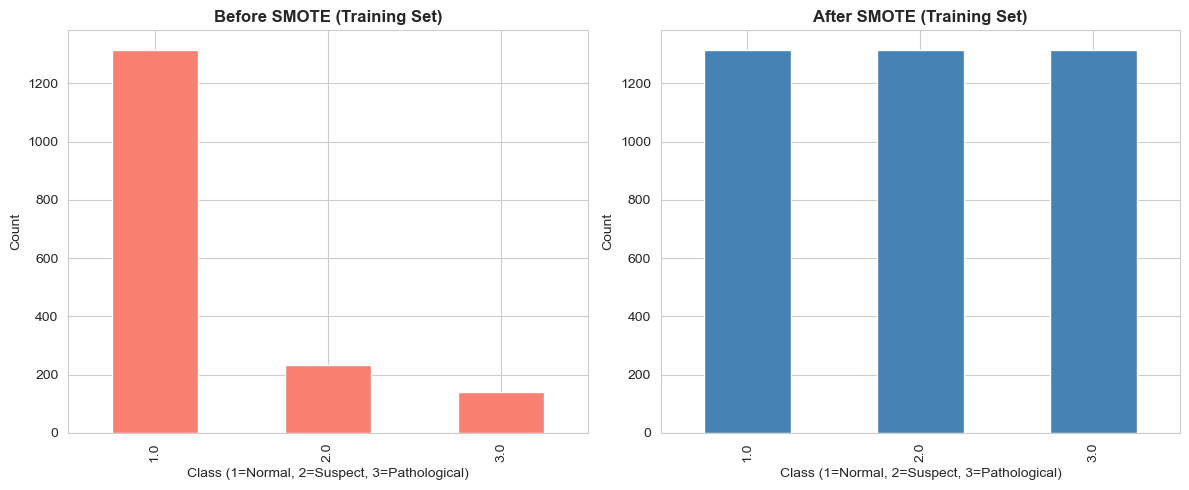

Figure saved: smote_before_after.png


In [23]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE — training class counts:")
print(y_train.value_counts().sort_index())

print("\nAfter SMOTE — training class counts:")
print(y_train_resampled.value_counts().sort_index())

print(f"\nTraining set size: {len(y_train)} → {len(y_train_resampled)}")

counts_after = y_train_resampled.value_counts()
assert counts_after.nunique() == 1, "SMOTE did not fully balance the classes"
print("Verified: training classes are now balanced")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_train.value_counts().sort_index().plot(kind="bar", color="salmon", ax=axes[0])
axes[0].set_title("Before SMOTE (Training Set)", fontweight="bold")
axes[0].set_xlabel("Class (1=Normal, 2=Suspect, 3=Pathological)")
axes[0].set_ylabel("Count")

y_train_resampled.value_counts().sort_index().plot(kind="bar", color="steelblue", ax=axes[1])
axes[1].set_title("After SMOTE (Training Set)", fontweight="bold")
axes[1].set_xlabel("Class (1=Normal, 2=Suspect, 3=Pathological)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../figures/smote_before_after.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved: smote_before_after.png")

## 6. Save Processed Data

Save the resampled training data and the scaled test data for use in modelling and
evaluation. The test set remains untouched by SMOTE, preserving real-world class
proportions for honest evaluation.

In [24]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

X_train_resampled.to_csv(output_dir / "X_train_resampled.csv", index=False)
y_train_resampled.to_csv(output_dir / "y_train_resampled.csv", index=False)
X_test_scaled.to_csv(output_dir / "X_test_scaled.csv", index=False)
y_test.to_csv(output_dir / "y_test.csv", index=False)

print("All processed files saved to data/processed/")
print("\nFiles ready for modelling (Gnaneshwar):")
print("- X_train_resampled.csv, y_train_resampled.csv  → use for training models")
print("- X_test_scaled.csv, y_test.csv                  → use for evaluating models")
print("- scaler.pkl                                      → saved for later external validation on CTU-UHB")

All processed files saved to data/processed/

Files ready for modelling (Gnaneshwar):
- X_train_resampled.csv, y_train_resampled.csv  → use for training models
- X_test_scaled.csv, y_test.csv                  → use for evaluating models
- scaler.pkl                                      → saved for later external validation on CTU-UHB


## 7. Preprocessing Summary

| Step | Detail |
|------|--------|
| Train/test split | 80/20, stratified by NSP (1,689 train / 423 test) |
| Scaling | StandardScaler, fit on training data only |
| SMOTE | Applied to training set only — balanced from 1,316/234/139 to 1,316/1,316/1,316 |
| Multicollinearity | Retained all features; deferred to SHAP for evidence-based simplification |
| Reproducibility | `random_state=42` used throughout |